In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

- 数据源：https://github.com/wri/global-power-plant-database/tree/master

## 探索性数据分析

In [2]:
df = pd.read_csv("data/global_power_plant_database.csv")

C:\Users\15499\AppData\Local\Temp\ipykernel_16352\879884981.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/global_power_plant_database.csv")


In [3]:
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [4]:
df0 = df[["country","latitude","longitude","capacity_mw","primary_fuel"]]
df0

,country,latitude,longitude,capacity_mw,primary_fuel
0,AFG,32.3220,65.1190,33.0,Hydro
1,AFG,31.6700,65.7950,10.0,Solar
2,AFG,31.6230,65.7920,10.0,Solar
3,AFG,34.5560,69.4787,66.0,Hydro
4,AFG,34.6410,69.7170,100.0,Hydro
...,...,...,...,...,...
34931,ZMB,-12.9667,28.6333,50.0,Oil
34932,ZMB,-12.8167,28.2000,20.0,Oil
34933,ZMB,-17.9167,25.8500,108.0,Hydro
34934,ZWE,-18.3835,26.4700,920.0,Coal


In [5]:
color_dict = {
    'Coal': '#000000',
    'Oil': '#a5582b',
    'Gas': '#b480be',
    'Hydro': '#4079b4',
    'Nuclear': '#d01724',
    'Solar': '#ee7e11',
    'Waste': '#663e9a',
    'Wind': '#6fa3d1',
    'Geothermal': '#f2be70',
    'Biomass': '#479a00',
    'Other': '#b9df89',
    'Cogeneration': '#e377c2',
    'Petcoke': '#8c564b',
    'Storage': '#17becf',
    'Wave and Tidal': '#1f77b4'
}

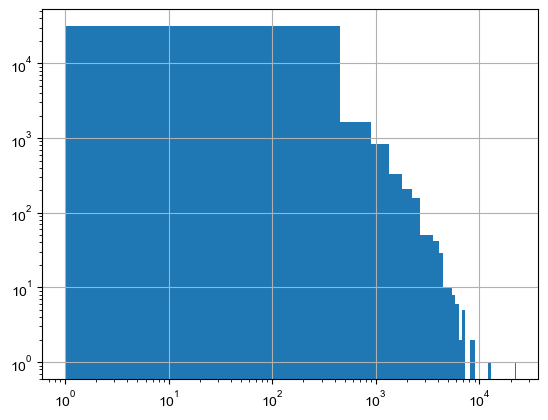

In [6]:
df0.capacity_mw.hist(bins=50)
plt.xscale("log")
plt.yscale("log")

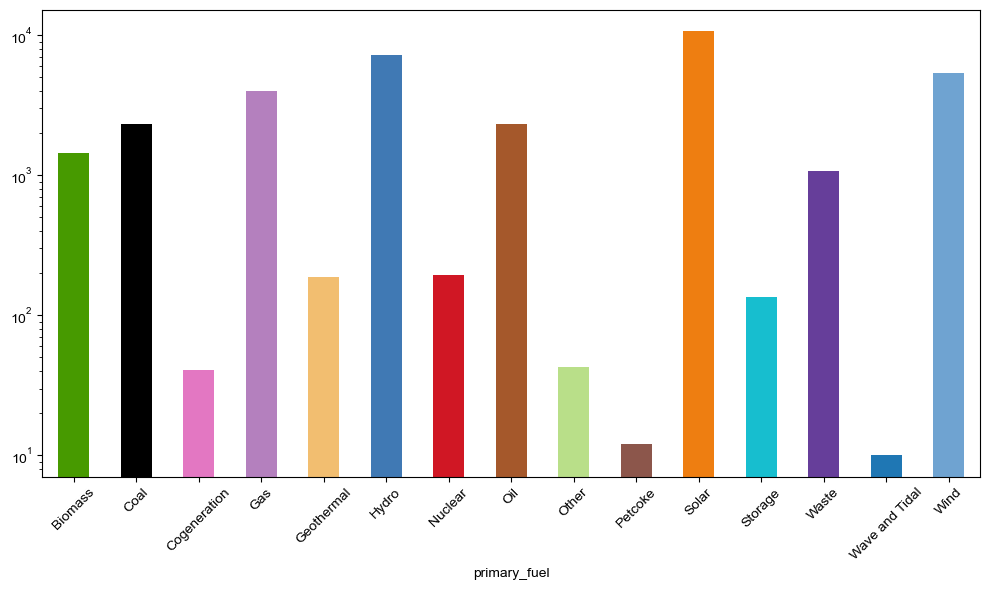

In [7]:
fuel_counts = df0.groupby("primary_fuel").size()
fuel_types = fuel_counts.index
colors = [color_dict.get(fuel, '#b9df89') for fuel in fuel_types]
fuel_counts.plot(kind="bar", color=colors, figsize=(10, 6))
plt.xticks(rotation=45)
plt.yscale("log")
plt.tight_layout()
plt.show()

In [8]:
top20_countries = df0.groupby("country")["capacity_mw"].sum().nlargest(20).index
top20_df = df0[df0["country"].isin(top20_countries)]

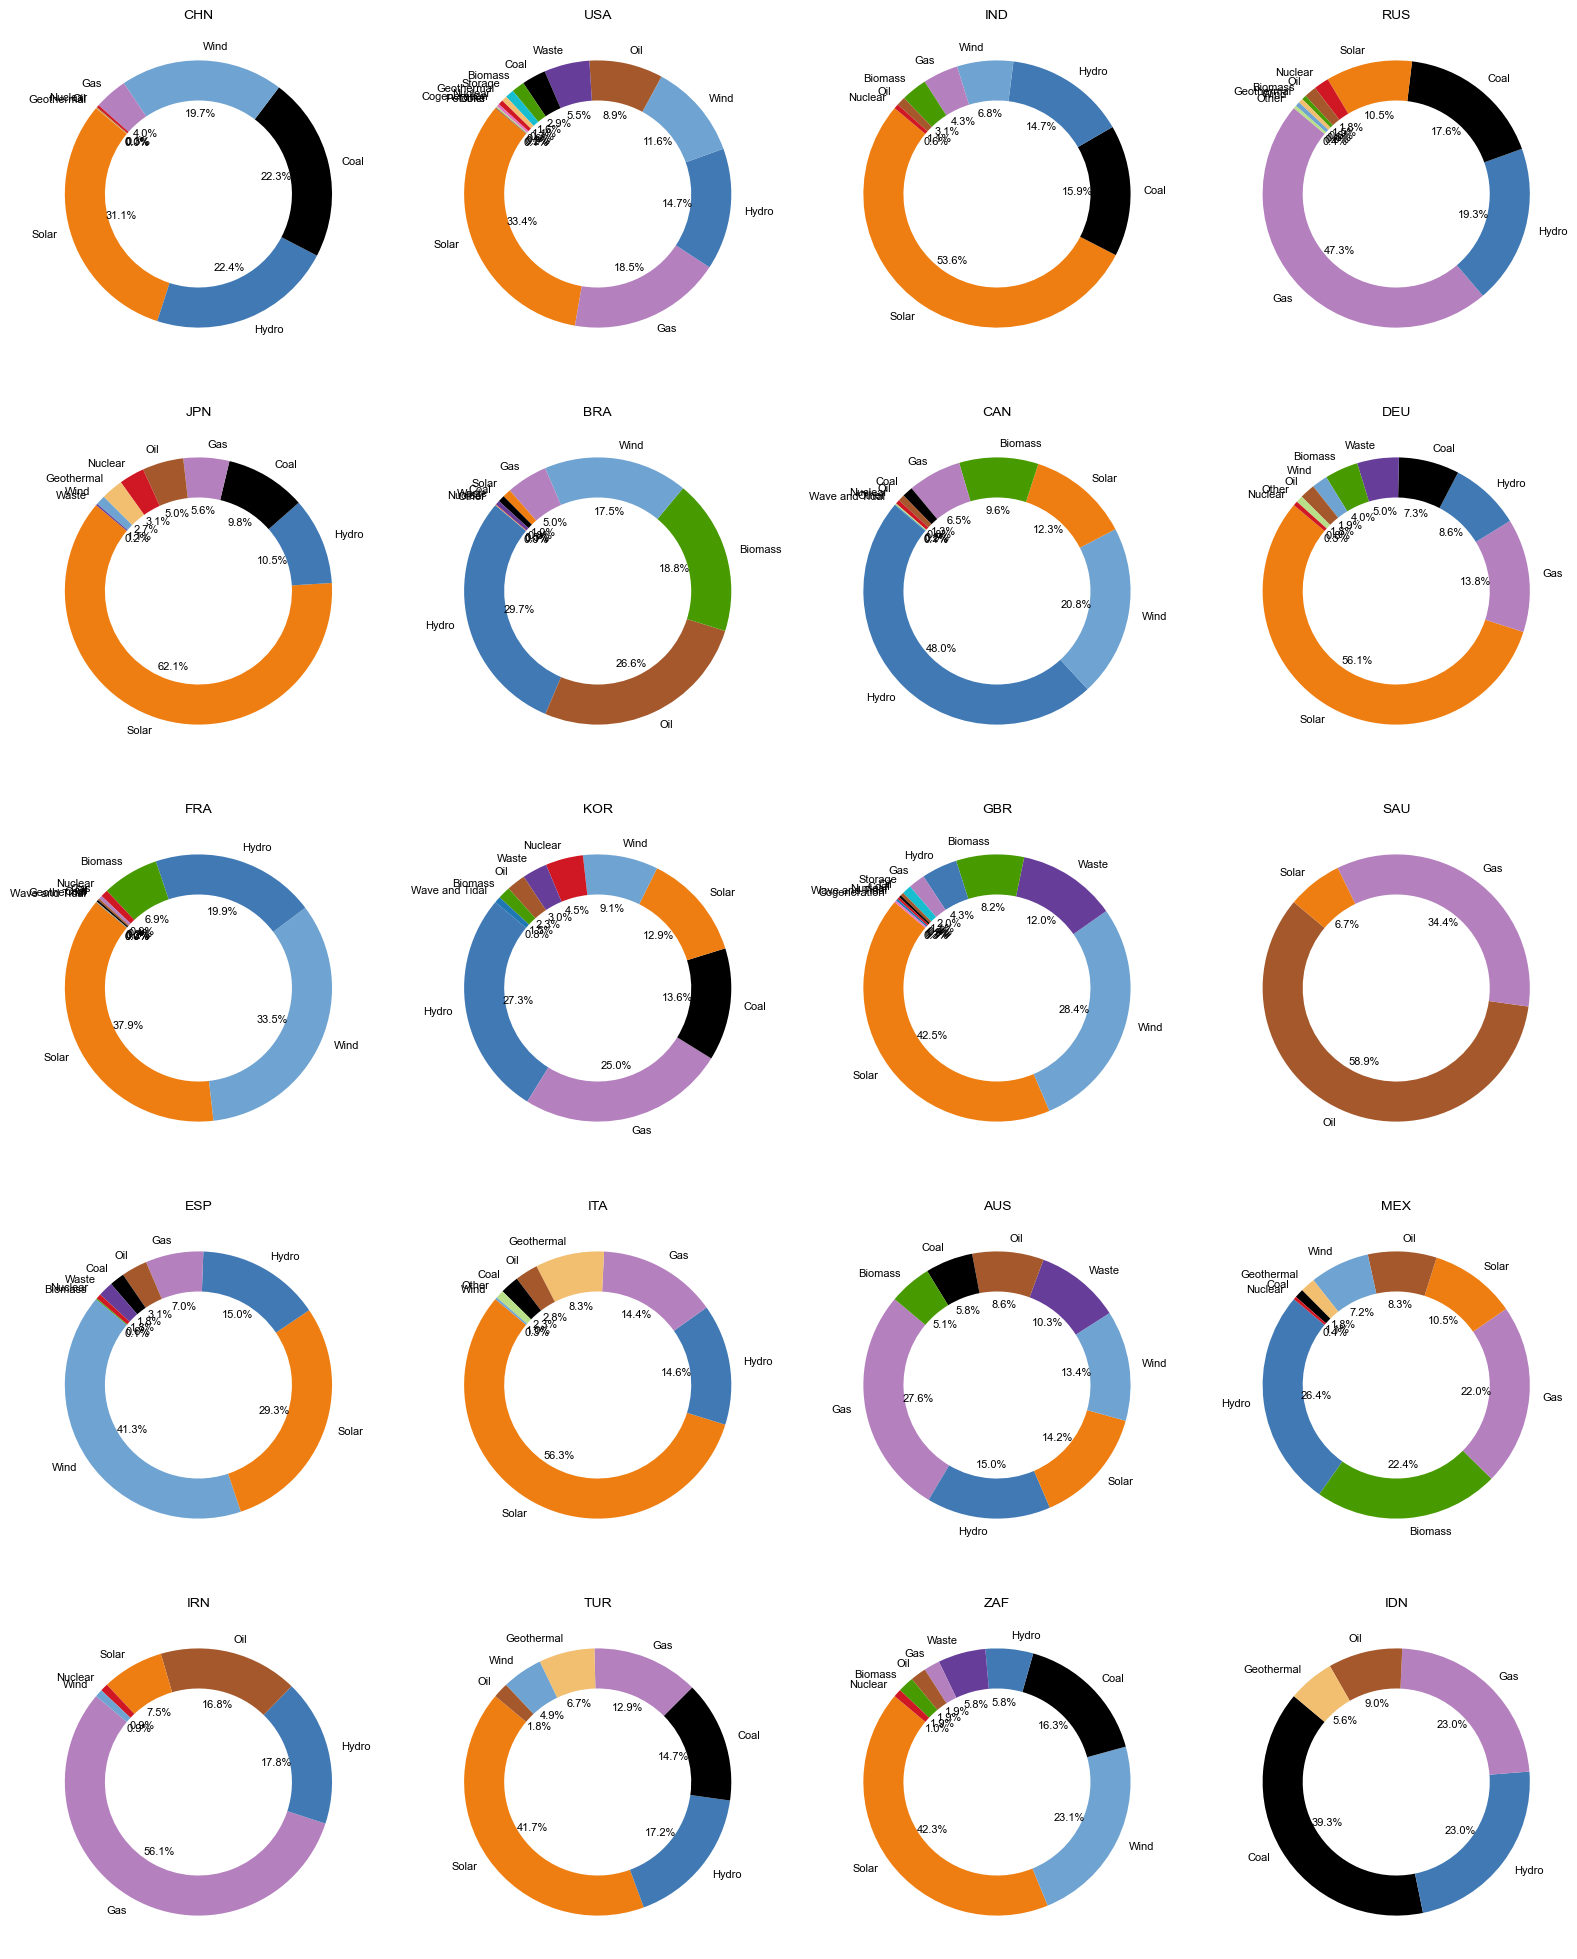

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(16, 20))

# 将 axes 展平为一维数组，方便循环索引
axes_flat = axes.flatten()

for i, country in enumerate(top20_countries):
    ax = axes_flat[i]
    country_data = top20_df[top20_df["country"] == country]
    fuel_counts = country_data["primary_fuel"].value_counts()
    
    # 获取燃料类型列表
    fuel_types = fuel_counts.index.tolist()
    
    # 根据颜色字典提取对应的颜色
    colors = [color_dict.get(fuel, '#b9df89') for fuel in fuel_types]  # 未匹配到的使用 Others 的颜色
    
    # 在指定的子图上绘制圆环图
    ax.pie(fuel_counts, 
           labels=fuel_types, 
           colors=colors,
           autopct='%1.1f%%', 
           startangle=140,
           wedgeprops={'width': 0.3},
           textprops={'fontsize': 8})
    ax.set_title(country, fontsize=10)

# 隐藏多余的子图
for j in range(len(top20_countries), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## 分布图

In [10]:
gdf = gpd.GeoDataFrame(df0, geometry=gpd.points_from_xy(df0.longitude, df0.latitude), crs="EPSG:4326")
world = gpd.read_file("../全球洪涝事件空间分布/data/全球国家区划矢量_去除南极洲.shp")

In [11]:
world_proj = world.to_crs('ESRI:54030')
gdf_proj = gdf.to_crs('ESRI:54030')

gdf_proj["lon"] = gdf_proj.geometry.x
gdf_proj["lat"] = gdf_proj.geometry.y

In [12]:
entozh = {
    'Coal': '煤炭',
    'Oil': '石油',
    'Gas': '天然气',
    'Hydro': '水力',
    'Nuclear': '核能',
    'Solar': '太阳能',
    'Waste': '垃圾发电',
    'Wind': '风能',
    'Geothermal': '地热能',
    'Biomass': '生物质能',
    'Other': '其他',
    'Cogeneration': '热电联产',
    'Petcoke': '石油焦',
    'Storage': '储能',
    'Wave and Tidal': '波浪/潮汐'
}

### 全球

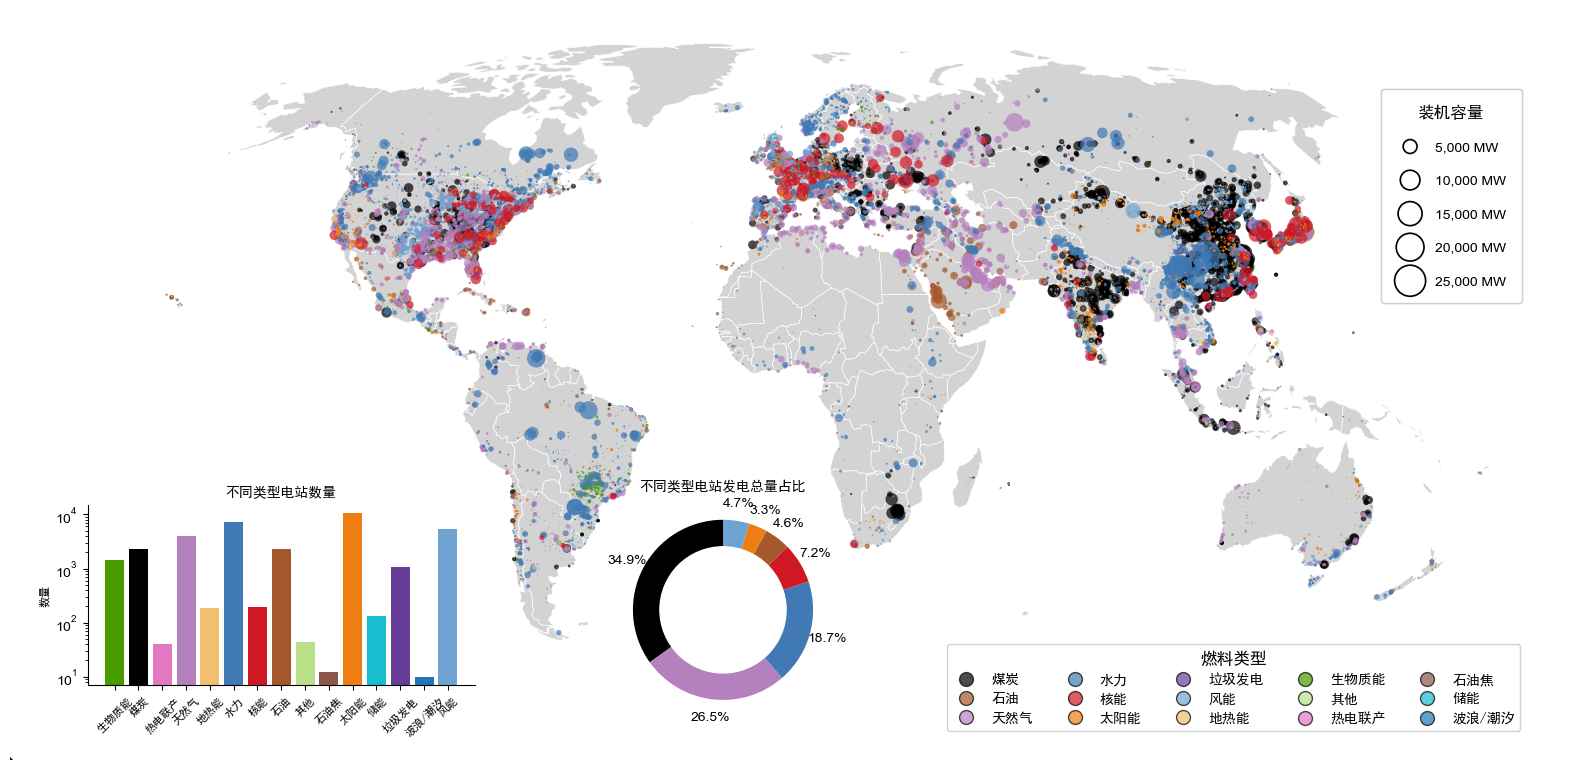

In [ ]:
fig, ax = plt.subplots(figsize=(20, 14))
ax.axis('off')

world_proj.plot(
    ax=ax, 
    color="lightgrey", 
    edgecolor="white", 
    linewidth=0.5
)
for fuel_type, color in color_dict.items():
    subset = gdf_proj[gdf_proj["primary_fuel"] == fuel_type]
    subset.plot(
        ax=ax, 
        markersize=subset["capacity_mw"] * 0.02, 
        color=color, 
        alpha=0.7,
        linewidth=0.0,
        label=fuel_type
    )

# 添加颜色图例
color_handles = []
for fuel_type, color in color_dict.items():
    # 检查该燃料类型是否存在于数据中
    if fuel_type in gdf_proj["primary_fuel"].values:
        color_handles.append(
            Line2D(
                [0], [0],
                marker='o',
                color='none',
                markerfacecolor=color,
                markersize=10,
                linewidth=0.0,
                label=entozh.get(fuel_type, fuel_type),
                alpha=0.7
            )
        )
legend_color = ax.legend(
    handles=color_handles,
    title="燃料类型",
    loc="lower left",
    bbox_to_anchor=(0.6, 0.03),
    fontsize=10,
    framealpha=0.9,
    ncol=5,
    prop={'family': 'SimHei', 'weight': 'bold'}
)
legend_color.get_title().set_fontproperties("SimHei")
legend_color.get_title().set_fontsize(12)
ax.add_artist(legend_color)

# 添加大小图例
size_values = [5000, 10000, 15000, 20000, 25000]
handles = [
    plt.scatter(
        [],
        [],
        s=v * 0.02,
        facecolors='none',
        edgecolors='black',
        linewidths=1.2
    )
    for v in size_values
]
labels = [f"{v:,} MW" for v in size_values]
legend_size = ax.legend(
    handles,
    labels,
    title="装机容量",
    scatterpoints=1,
    loc="lower left",
    bbox_to_anchor=(0.88, 0.6),
    fontsize=10,
    framealpha=0.9,
    labelspacing=1.5,
    borderpad=1.1,
)
legend_size.get_title().set_fontproperties("SimHei")
legend_size.get_title().set_fontsize(12)
ax.add_artist(legend_size)

# 柱状图
ax_bar = inset_axes(
    ax,
    width="25%",
    height="24%",
    loc='lower left',
    bbox_to_anchor=(0.05, 0.1, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
fuel_counts = df0.groupby("primary_fuel").size()
fuel_types = fuel_counts.index
colors = [color_dict.get(fuel, '#b9df89') for fuel in fuel_types]
ax_bar.bar(range(len(fuel_counts)), fuel_counts.values, color=colors)
ax_bar.set_xticks(range(len(fuel_counts)))
ax_bar.set_xticklabels([entozh.get(fuel, fuel) for fuel in fuel_types], rotation=45, ha='center', fontsize=8)
ax_bar.set_title("不同类型电站数量", fontproperties="SimHei", fontsize=10)
ax_bar.set_yscale("log")
ax_bar.set_xticklabels(ax_bar.get_xticklabels(), fontproperties="SimHei", fontsize=8)
ax_bar.set_ylabel("数量", fontproperties="SimHei", fontsize=8)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['top'].set_visible(False)


# 柱状图
ax_pie = inset_axes(
    ax,
    width="30%",
    height="30%",
    loc='lower left',
    bbox_to_anchor=(0.31, 0.05, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
generation_by_fuel = df0.groupby("primary_fuel")["capacity_mw"].sum()
generation_by_fuel = generation_by_fuel[generation_by_fuel > generation_by_fuel.sum() * 0.01]
fuel_types_pie = generation_by_fuel.index
sizes = generation_by_fuel.values
colors_pie = [color_dict.get(fuel, '#b9df89') for fuel in fuel_types_pie]
wedges, texts, autotexts = ax_pie.pie(
    sizes,
    labels=None,
    colors=colors_pie,
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',  # 小于3%不显示百分比
    startangle=90,
    pctdistance=1.2
)
centre_circle = plt.Circle((0, 0), 0.70, fc='white', edgecolor='white', linewidth=1)
ax_pie.add_artist(centre_circle)
ax_pie.set_title("不同类型电站发电总量占比", fontproperties="SimHei", fontsize=10, pad=5)


plt.savefig("fig/global_power_plant_distribution.png", dpi=800, bbox_inches='tight')
plt.show()

### 中国

In [14]:
gdf_chn = gdf_proj.query("country=='CHN'").copy()
gdf_chn['geometry'] = gpd.points_from_xy(
    gdf_chn['longitude'], 
    gdf_chn['latitude'],
    crs="EPSG:4326"
)
gdf_chn = gdf_chn.to_crs(
    "+proj=aea +lat_1=25 +lat_2=47 +lat_0=35 +lon_0=105 +x_0=0 +y_0=0 +ellps=WGS84 +units=m +no_defs"
)

<Axes: >

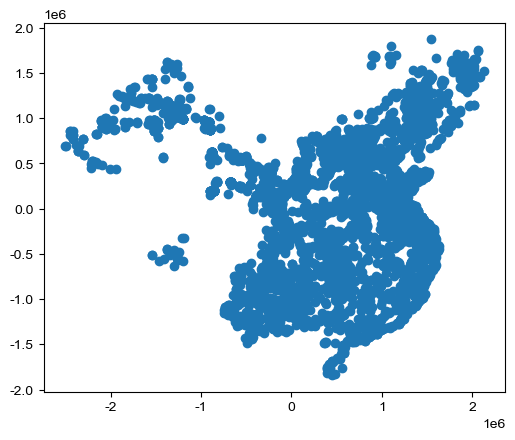

In [15]:
gdf_chn.plot()

C:\Users\15499\AppData\Local\Temp\ipykernel_16352\2683613825.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(
C:\Users\15499\AppData\Local\Temp\ipykernel_16352\2683613825.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(
C:\Users\15499\AppData\Local\Temp\ipykernel_16352\2683613825.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(
C:\Users\15499\AppData\Local\Temp\ipykernel_16352\2683613825.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(
C:\Users\15499\AppData\Local\Temp\ipykernel_16352\2683613825.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(
C:\Users\15499\AppData\Local\Temp\ipykernel_16352\2683613825.py:6: UserWarning: The GeoDataFrame you are attempting

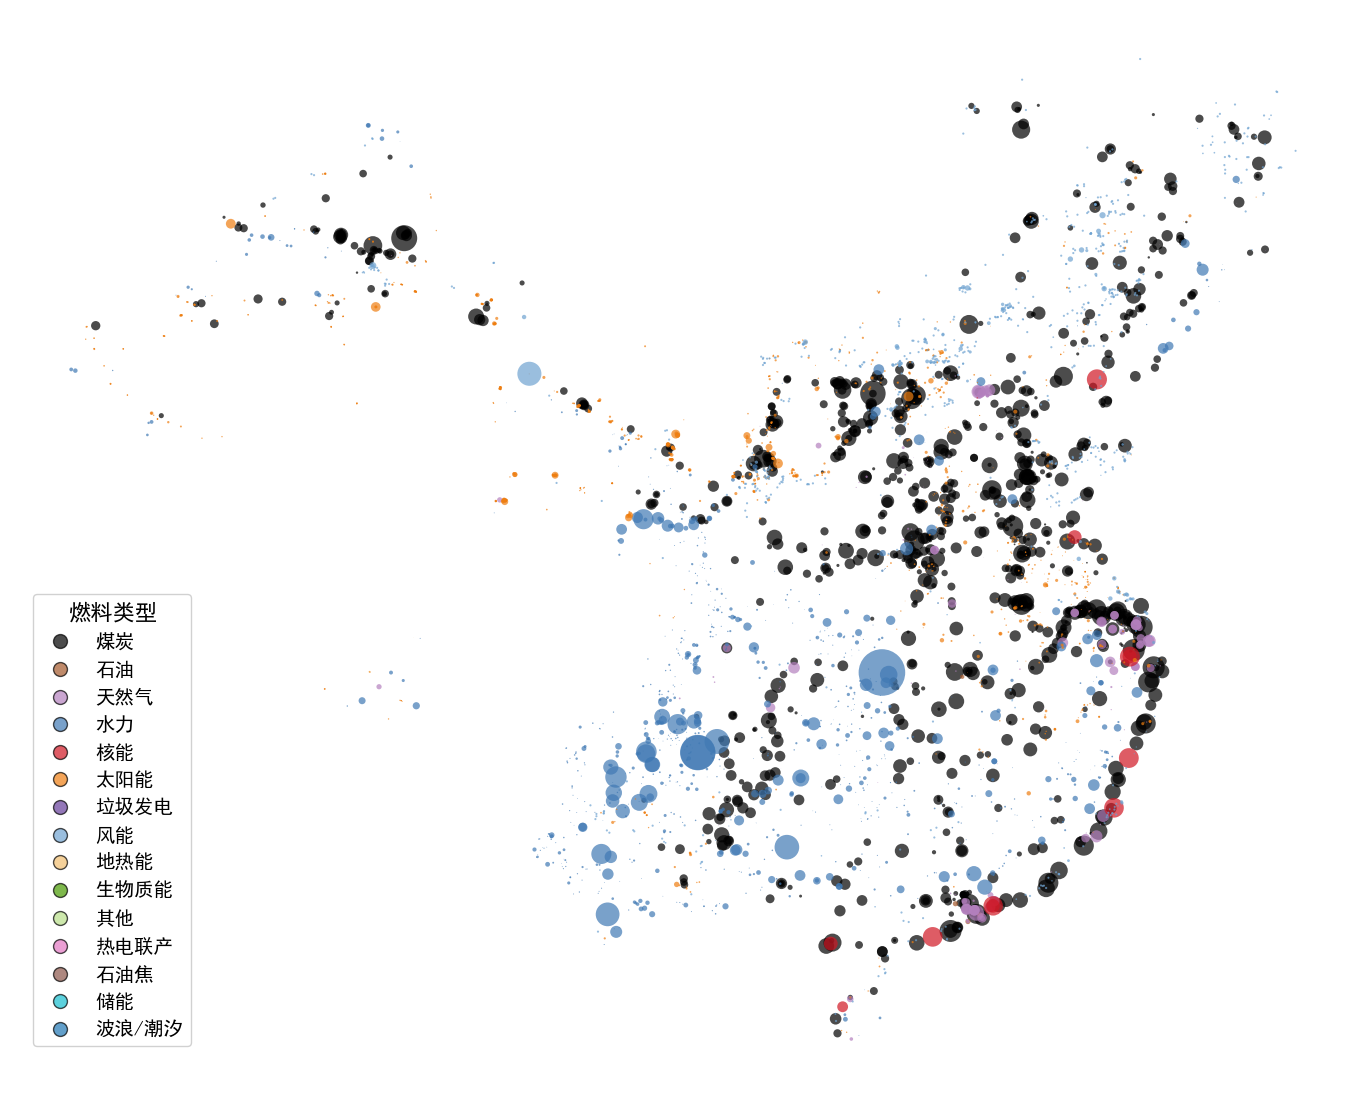

In [ ]:
fig, ax = plt.subplots(figsize=(20, 14))
ax.axis('off')

for fuel_type, color in color_dict.items():
    subset = gdf_chn[gdf_chn["primary_fuel"] == fuel_type]
    subset.plot(
        ax=ax, 
        markersize=subset["capacity_mw"] * 0.05, 
        color=color, 
        alpha=0.7,
        linewidth=0.0,
        label=fuel_type
    )

color_handles = []
for fuel_type, color in color_dict.items():
    # 检查该燃料类型是否存在于数据中
    if fuel_type in gdf_proj["primary_fuel"].values:
        color_handles.append(
            Line2D(
                [0], [0],
                marker='o',
                color='none',
                markerfacecolor=color,
                markersize=10,
                linewidth=0.0,
                label=entozh.get(fuel_type, fuel_type),
                alpha=0.7
            )
        )
legend_color = ax.legend(
    handles=color_handles,
    title="燃料类型",
    loc="lower left",
    bbox_to_anchor=(0.01, 0.03),
    framealpha=0.9,
    ncol=1,
    prop={'family': 'SimHei', 'size': 14}
)
legend_color.get_title().set_fontproperties("SimHei")
legend_color.get_title().set_fontsize(16)

plt.savefig("fig/chn.png", dpi=500, bbox_inches='tight')
plt.show()

### 美国

In [17]:
gdf_usa = gdf_proj.query("country=='USA'")
gdf_usa0 = gdf_usa[
    (gdf_usa['longitude'] >= -124.8) & 
    (gdf_usa['longitude'] <= -66.9) &
    (gdf_usa['latitude'] >= 24.4) & 
    (gdf_usa['latitude'] <= 49.4)
].copy()

In [18]:
gdf_usa0

,country,latitude,longitude,capacity_mw,primary_fuel,geometry,lon,lat
24710,USA,41.0930,-73.9828,2.0,Solar,POINT (-6405108.768 4392384.713),-6.405109e+06,4.392385e+06
24711,USA,35.4273,-79.1263,5.0,Solar,POINT (-7034933.51 3788972.014),-7.034934e+06,3.788972e+06
24712,USA,36.1971,-80.8067,3.0,Solar,POINT (-7161181.051 3871186.598),-7.161181e+06,3.871187e+06
24713,USA,40.2003,-74.5761,1.9,Solar,POINT (-6486700.587 4297631.936),-6.486701e+06,4.297632e+06
24714,USA,42.0761,-71.4227,2.0,Solar,POINT (-6150487.137 4496551.552),-6.150487e+06,4.496552e+06
...,...,...,...,...,...,...,...,...
34538,USA,42.4803,-87.8861,7.0,Waste,POINT (-7551169.478 4539320.686),-7.551169e+06,4.539321e+06
34539,USA,38.2803,-85.7023,18.0,Gas,POINT (-7524821.829 4093373.473),-7.524822e+06,4.093373e+06
34540,USA,42.8869,-76.9683,3.4,Wind,POINT (-6597931.435 4582307.381),-6.597931e+06,4.582307e+06
34541,USA,44.3195,-92.6703,1.0,Solar,POINT (-7878211.632 4733456.736),-7.878212e+06,4.733457e+06


In [19]:
gdf_usa0['geometry'] = gpd.points_from_xy(
    gdf_usa0['longitude'], 
    gdf_usa0['latitude'],
    crs="EPSG:4326"
)
gdf_usa0 = gdf_usa0.to_crs("EPSG:5070")

<Axes: >

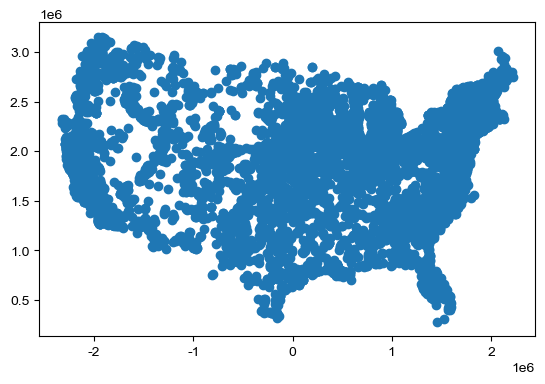

In [20]:
gdf_usa0.plot()

C:\Users\15499\AppData\Local\Temp\ipykernel_16352\187839155.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  subset.plot(


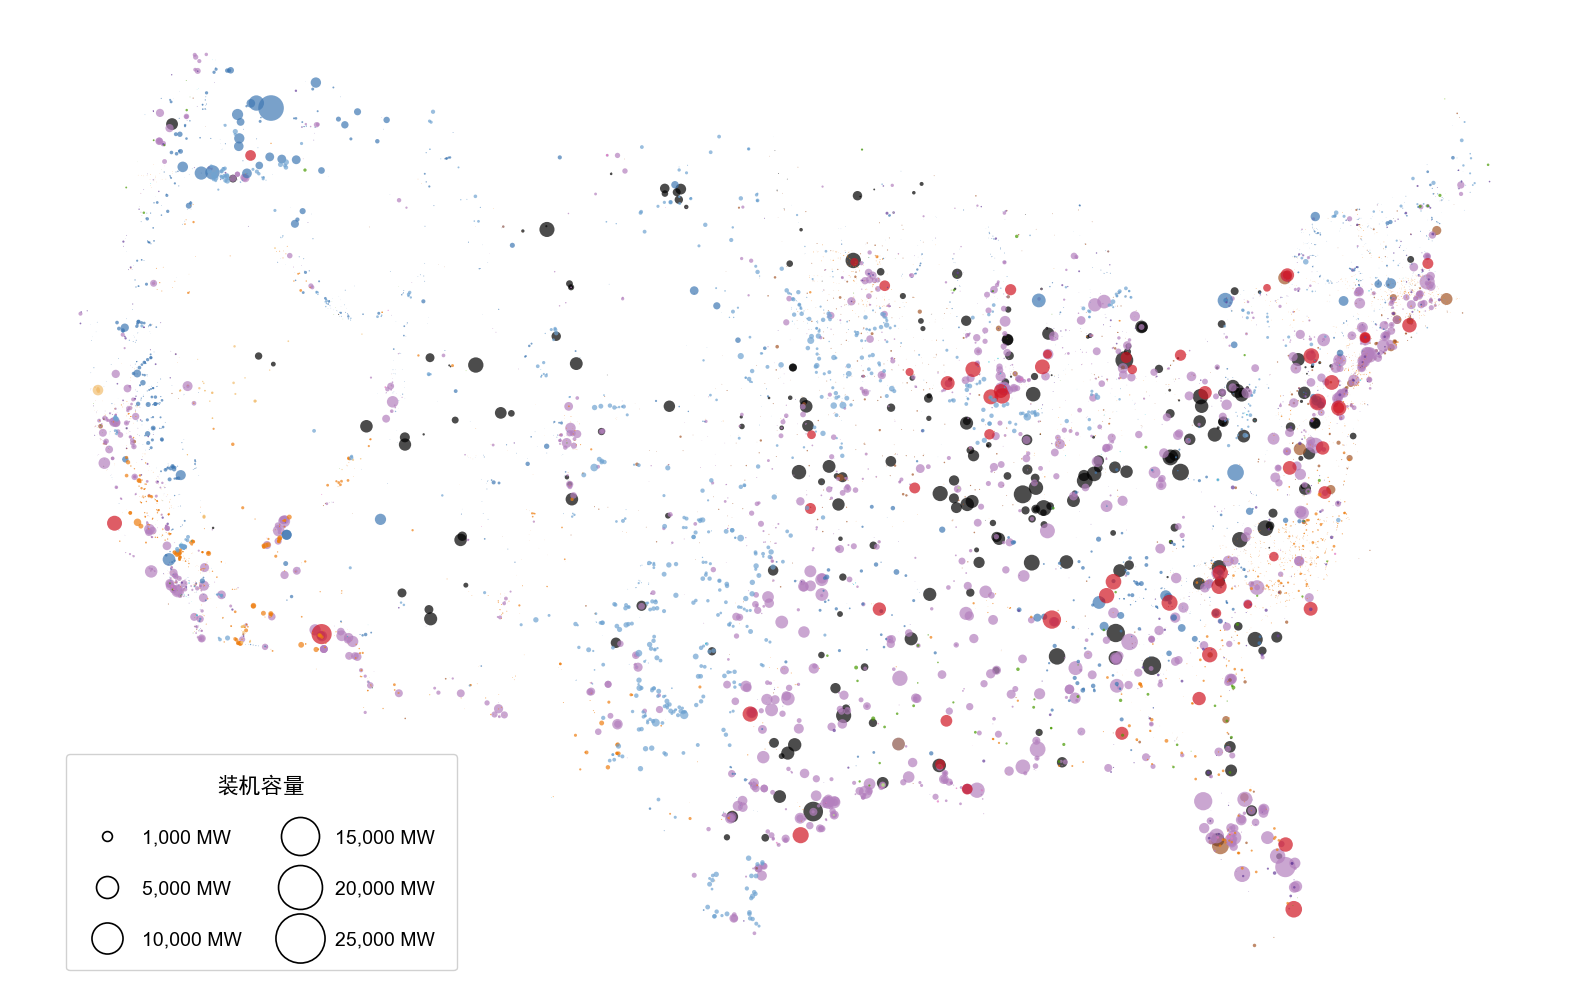

In [ ]:
fig, ax = plt.subplots(figsize=(20, 14))
ax.axis('off')

for fuel_type, color in color_dict.items():
    subset = gdf_usa0[gdf_usa0["primary_fuel"] == fuel_type]
    subset.plot(
        ax=ax, 
        markersize=subset["capacity_mw"] * 0.05, 
        color=color, 
        alpha=0.7,
        linewidth=0.0,
        label=fuel_type
    )

# 添加大小图例
size_values = [1000, 5000, 10000, 15000, 20000, 25000]
handles = [
    Line2D([0], [0], 
           marker='o', 
           color='w', 
           markerfacecolor='none', 
           markeredgecolor='black',
           markersize=(v * 0.05) ** 0.5,  # markersize 是半径，需要开方
           markeredgewidth=1.2,
           linestyle='none')
    for v in size_values
]

labels = [f"{v:,} MW" for v in size_values]
legend_size = ax.legend(
    handles,
    labels,
    title="装机容量",
    loc="lower left",
    bbox_to_anchor=(0.03, 0.01),
    fontsize=14,
    ncol=2,
    framealpha=0.9,
    labelspacing=1.7,
    borderpad=1.1,
)
legend_size.get_title().set_fontproperties("SimHei")
legend_size.get_title().set_fontsize(16)

plt.savefig("fig/usa.png", dpi=500, bbox_inches='tight')
plt.show()